In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')   # Modeling/ → pipeline 패키지 import
sys.path.insert(0, '..')  # ../config.py 참조

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import norm

import config
from pipeline import comparison as cmp
from viz_style import apply_style
apply_style()

CV_DIR      = config.CV_RESULTS_DIR
PALETTE     = cmp.PALETTE
MODEL_ORDER = cmp.MODEL_ORDER
ETP_THR     = cmp.ETP_THR
W1_EXPECTED = cmp.W1_EXPECTED
METRIC_DEFS = cmp.METRIC_DEFS

nb, zinb, logr, rare, nb_z, zinb_z, logr_z, rare_z = cmp.load_cv_outputs()
for name, df in [('NBI', nb), ('ZINBI', zinb), ('Logistic', logr), ('Rare', rare)]:
    print(f"{name:10s}: " + (f"{len(df):,} genes" if df is not None else "not found"))


NBI       : 16,570 genes
ZINBI     : 16,572 genes
Logistic  : 2,968 genes
Rare      : 559 genes


In [2]:
all_df, models_present = cmp.build_all_df(nb, zinb, logr, rare, nb_z, zinb_z, logr_z, rare_z)

rows_tbl = []
for model in models_present:
    sub = all_df[all_df['model'] == model]
    row = {'Model': model, 'N': f'{len(sub):,}',
           'Flag %': f'{sub["any_flag"].mean()*100:.1f}%',
           'Fold ok': f'{(sub["fold_ok"]==1.0).mean()*100:.1f}%'}
    for col, label, _, _ in METRIC_DEFS:
        v = sub[col].dropna()
        q25, med, q75 = v.quantile([0.25, 0.5, 0.75])
        row[label] = f'{med:.3f}  ({q25:.3f}–{q75:.3f})'
    rows_tbl.append(row)

summary_df = pd.DataFrame(rows_tbl).set_index('Model')
summary_df

,N,Flag %,Fold ok,W1 ↓,ETP ↓ (→0.05),Skewness → 0,Kurtosis → 0,Z-mean → 0,Z-std → 1
Model,,,,,,,,,
NBI,"16,570",0.0%,99.5%,0.064 (0.054–0.076),0.062 (0.058–0.068),-0.036 (-0.212–0.149),0.767 (0.353–1.330),0.004 (-0.004–0.011),1.063 (1.052–1.075)
ZINBI,"16,572",54.5%,96.1%,0.056 (0.045–0.071),0.056 (0.051–0.063),0.207 (0.051–0.377),0.556 (0.169–1.263),0.016 (0.004–0.029),1.040 (1.017–1.065)
Logistic,"2,968",0.0%,100.0%,0.048 (0.043–0.051),0.043 (0.040–0.048),0.055 (0.017–0.095),0.355 (0.262–0.462),0.003 (-0.001–0.006),0.963 (0.956–0.971)
Rare,559,95.0%,100.0%,0.052 (0.041–0.068),0.048 (0.042–0.052),0.157 (0.014–0.418),0.692 (0.055–3.026),-0.009 (-0.040–0.018),1.008 (0.988–1.030)


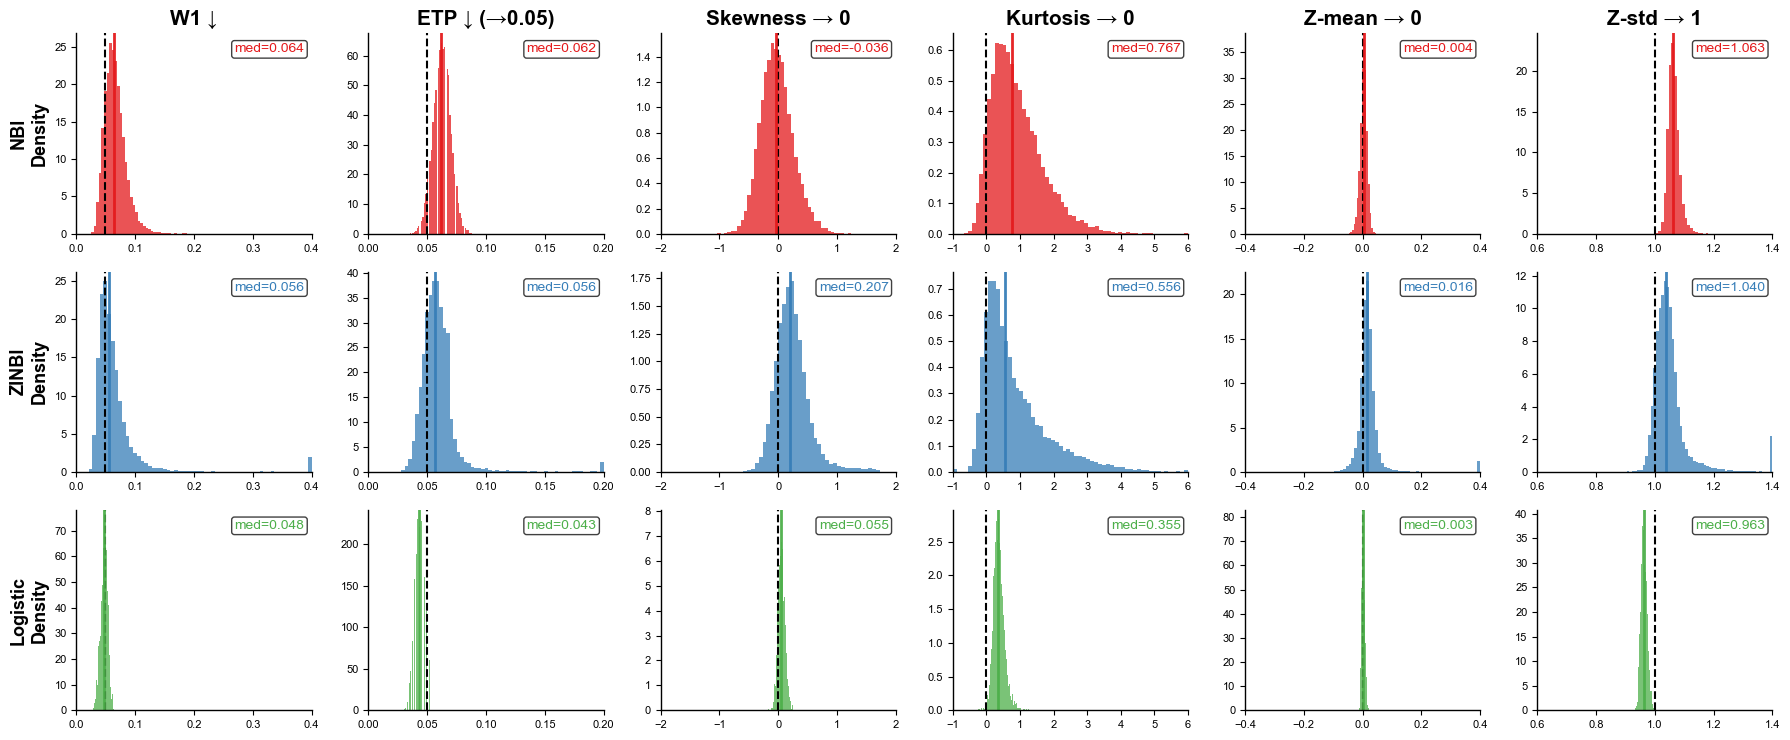

In [3]:
# Rare is a pooled model with ~3 nonzero obs/gene, so its per-gene higher-moment metrics
# (skew/kurtosis/W1) are data-starved and not interpretable. It is excluded from these
# per-gene panels and shown only in the dedicated pooled-calibration section below.
pergene_models = [m for m in models_present if m != 'Rare']
n_models = len(pergene_models)
fig, axes = plt.subplots(n_models, 6,
                          figsize=(18, 2.5 * n_models),
                          squeeze=False)

for row, model in enumerate(pergene_models):
    sub   = all_df[all_df['model'] == model]
    color = PALETTE[model]

    for col, (metric, label, xlim, ref) in enumerate(METRIC_DEFS):
        ax   = axes[row, col]
        vals = sub[metric].dropna().clip(*xlim)
        med  = vals.median()

        ax.hist(vals, bins=60, color=color, alpha=0.75,
                density=True, edgecolor='none')
        ax.axvline(ref, color='black', lw=1.5, ls='--')
        ax.axvline(med, color=color,   lw=2.0, ls='-', alpha=0.95)
        ax.set_xlim(*xlim)
        ax.tick_params(labelsize=8)

        if col == 0:
            ax.set_ylabel(f'{model}\nDensity', fontweight='bold')
        else:
            ax.set_ylabel('')

        if row == 0:
            ax.set_title(label, fontweight='bold')

        ax.annotate(f'med={med:.3f}',
                    xy=(0.97, 0.95), xycoords='axes fraction',
                    ha='right', va='top', color=color,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75))

plt.tight_layout()
plt.savefig(CV_DIR / "Figures" / 'fig_metrics_grid.png', bbox_inches='tight')
plt.show()

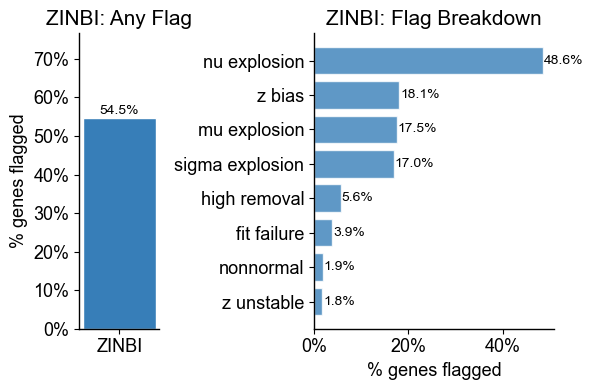

In [4]:
if zinb is not None:
    flag_cols = [c for c in zinb.columns if c.startswith('flag_') and c != 'any_flag']
    pcts      = (zinb[flag_cols].mean() * 100).sort_values(ascending=True)
    labels    = [c.replace('flag_', '').replace('_', ' ') for c in pcts.index]
    rate_any  = zinb['any_flag'].mean() * 100

    n_cols = 2
    fig, (ax_bar, ax_bdown) = plt.subplots(1, n_cols, figsize=(6, 4), width_ratios=(0.5, 1.5))

    ax_bar.bar(['ZINBI'], [rate_any], color=PALETTE['ZINBI'], edgecolor='white')
    ax_bar.text(0, rate_any + 0.4, f'{rate_any:.1f}%', ha='center', va='bottom')
    ax_bar.set_ylim(0, max(rate_any * 1.35 + 3, 10))
    ax_bar.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax_bar.set_title('ZINBI: Any Flag')
    ax_bar.set_ylabel('% genes flagged')

    bars = ax_bdown.barh(labels, pcts.values, color=PALETTE['ZINBI'], alpha=0.8, edgecolor='white')
    for bar, v in zip(bars, pcts.values):
        ax_bdown.text(v + 0.2, bar.get_y() + bar.get_height() / 2, f'{v:.1f}%', va='center')
    ax_bdown.set_title('ZINBI: Flag Breakdown')
    ax_bdown.set_xlabel('% genes flagged')
    ax_bdown.xaxis.set_major_formatter(mticker.PercentFormatter())

    plt.tight_layout()
    plt.savefig(CV_DIR / "Figures" / 'fig_flags.png', bbox_inches='tight')
    plt.show()
else:
    print("ZINBI stats not loaded.")


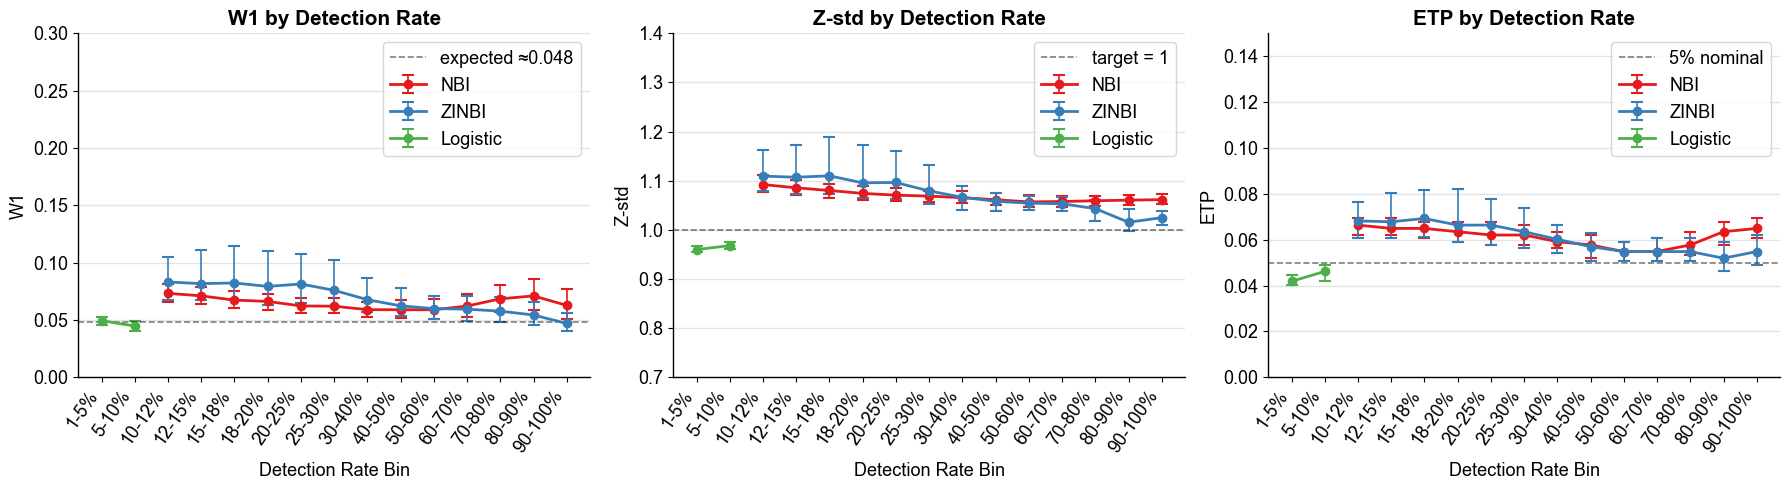

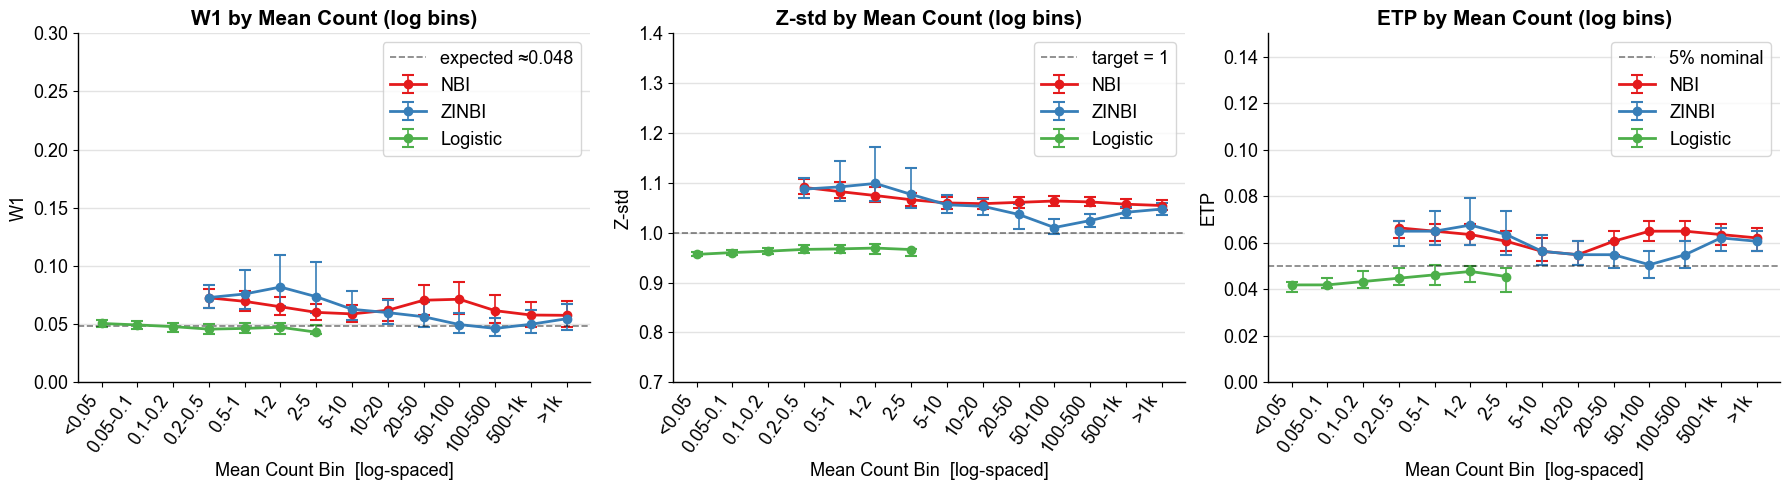

In [5]:
EB_METRICS = [
    ('w1',    'W1',    (0.00, 0.30), W1_EXPECTED, f'expected ≈{W1_EXPECTED}'),
    ('std_z', 'Z-std', (0.70, 1.40), 1.0,         'target = 1'),
    ('etp',   'ETP',   (0.00, 0.15), 0.05,        '5% nominal'),
]

# Rare excluded: pooled model, all rare genes sit in the lowest mean-count/det-rate bins
# with ~3 nonzero obs each, so per-bin per-gene metrics are not interpretable for it.
pergene_models = [m for m in models_present if m != 'Rare']


def _errorbar_plot(ax, sub_df, metric, model, bin_col, bins, labels):
    sub = sub_df.copy()
    sub[bin_col] = pd.cut(sub['det_rate'] if bin_col == 'det_bin' else sub['mean_count'],
                           bins=bins, labels=labels, right=False)
    grp = sub.groupby(bin_col, observed=False)[metric]
    med, q25, q75, cnt = (grp.median(), grp.quantile(0.25),
                           grp.quantile(0.75), grp.count())
    x    = np.arange(len(med))
    mask = cnt > 2
    ax.errorbar(x[mask], med.values[mask],
                yerr=[med.values[mask] - q25.values[mask],
                      q75.values[mask] - med.values[mask]],
                fmt='o-', color=PALETTE[model], label=model,
                lw=2, ms=6, capsize=4, capthick=1.5, elinewidth=1.2)

# ── Figure 1: Detection Rate bins ────────────────────────────────
DET_BINS = np.array([0.01, 0.05, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25,
                     0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00])
DET_LABELS = [f'{int(DET_BINS[i]*100)}-{int(DET_BINS[i+1]*100)}%'
              for i in range(len(DET_BINS) - 1)]

fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
for ax, (metric, label, ylim, ref, ref_label) in zip(axes1, EB_METRICS):
    for model in pergene_models:
        _errorbar_plot(ax, all_df[all_df['model'] == model],
                       metric, model, 'det_bin', DET_BINS, DET_LABELS)
    ax.axhline(ref, color='black', lw=1.2, ls='--', alpha=0.5, label=ref_label)
    ax.set_xticks(range(len(DET_LABELS)))
    ax.set_xticklabels(DET_LABELS, rotation=55, ha='right')
    ax.set_ylim(*ylim)
    ax.set_title(f'{label} by Detection Rate', fontweight='bold')
    ax.set_xlabel('Detection Rate Bin')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig(CV_DIR / "Figures" /'fig_detrate.png', bbox_inches='tight')
plt.show()

# ── Figure 2: Mean Count log bins ────────────────────────────────
# log-uniform bin edges covering sparse gap genes (~0.01) to highly expressed (~100k)
MEAN_BINS = np.array([0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0,
                       20.0, 50.0, 100.0, 500.0, 1000.0, np.inf])
MEAN_LABELS = ['<0.05', '0.05-0.1', '0.1-0.2', '0.2-0.5', '0.5-1',
               '1-2', '2-5', '5-10', '10-20', '20-50',
               '50-100', '100-500', '500-1k', '>1k']

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
for ax, (metric, label, ylim, ref, ref_label) in zip(axes2, EB_METRICS):
    for model in pergene_models:
        sub = all_df[all_df['model'] == model].copy()
        sub['mean_bin'] = pd.cut(sub['mean_count'], bins=MEAN_BINS,
                                  labels=MEAN_LABELS, right=False)
        grp  = sub.groupby('mean_bin', observed=False)[metric]
        med, q25, q75, cnt = (grp.median(), grp.quantile(0.25),
                               grp.quantile(0.75), grp.count())
        x    = np.arange(len(med))
        mask = cnt > 2
        ax.errorbar(x[mask], med.values[mask],
                    yerr=[med.values[mask] - q25.values[mask],
                          q75.values[mask] - med.values[mask]],
                    fmt='o-', color=PALETTE[model], label=model,
                    lw=2, ms=6, capsize=4, capthick=1.5, elinewidth=1.2)
    ax.axhline(ref, color='black', lw=1.2, ls='--', alpha=0.5, label=ref_label)
    ax.set_xticks(range(len(MEAN_LABELS)))
    ax.set_xticklabels(MEAN_LABELS, rotation=55, ha='right')
    ax.set_ylim(*ylim)
    ax.set_title(f'{label} by Mean Count (log bins)', fontweight='bold')
    ax.set_xlabel('Mean Count Bin  [log-spaced]')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig(CV_DIR / "Figures" / 'fig_meancount.png', bbox_inches='tight')
plt.show()

,mean,std,P0,P25,P50,P75,P90,P95,P99,P100
model,,,,,,,,,,
NBI,0.12,0.64,0.0,0.0,0.0,0.0,0.0,0.0,4.0,10.0
ZINBI,4.76,18.13,0.0,0.0,0.0,0.0,7.0,33.0,101.0,234.0
Rare,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


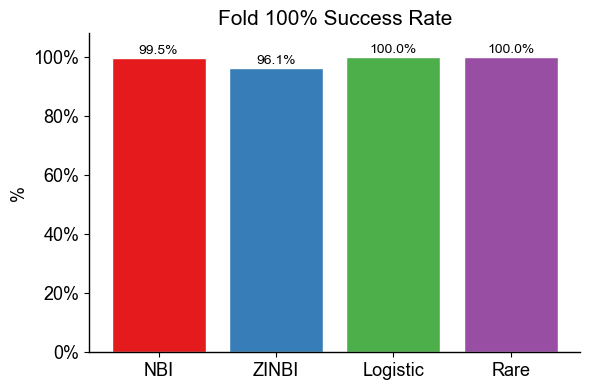

In [6]:
# ── Outlier removal summary table ────────────────────────────────
count_models = [m for m in models_present if m != 'Logistic']
pctiles = [0, 25, 50, 75, 90, 95, 99, 100]

rows = []
for model in count_models:
    vals = all_df[all_df['model'] == model]['n_removed']
    row  = {'model': model, 'mean': round(vals.mean(), 2), 'std': round(vals.std(), 2)}
    row.update({f'P{p}': round(np.percentile(vals, p), 1) for p in pctiles})
    rows.append(row)

outlier_table = pd.DataFrame(rows).set_index('model')
display(outlier_table)

# ── Fold 100% success rate ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
fold_ok_full = (all_df.groupby('model')['fold_ok']
                .apply(lambda x: (x == 1.0).mean() * 100)
                .reindex(models_present))
bars = ax.bar(fold_ok_full.index, fold_ok_full.values,
              color=[PALETTE[m] for m in fold_ok_full.index],
              edgecolor='white')
for bar, v in zip(bars, fold_ok_full.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f'{v:.1f}%',
            ha='center', va='bottom')
ax.set_ylim(0, 108)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Fold 100% Success Rate')
ax.set_ylabel('%')
plt.tight_layout()
plt.savefig(CV_DIR / "Figures" / 'fig_fold_success.png', bbox_inches='tight')
plt.show()


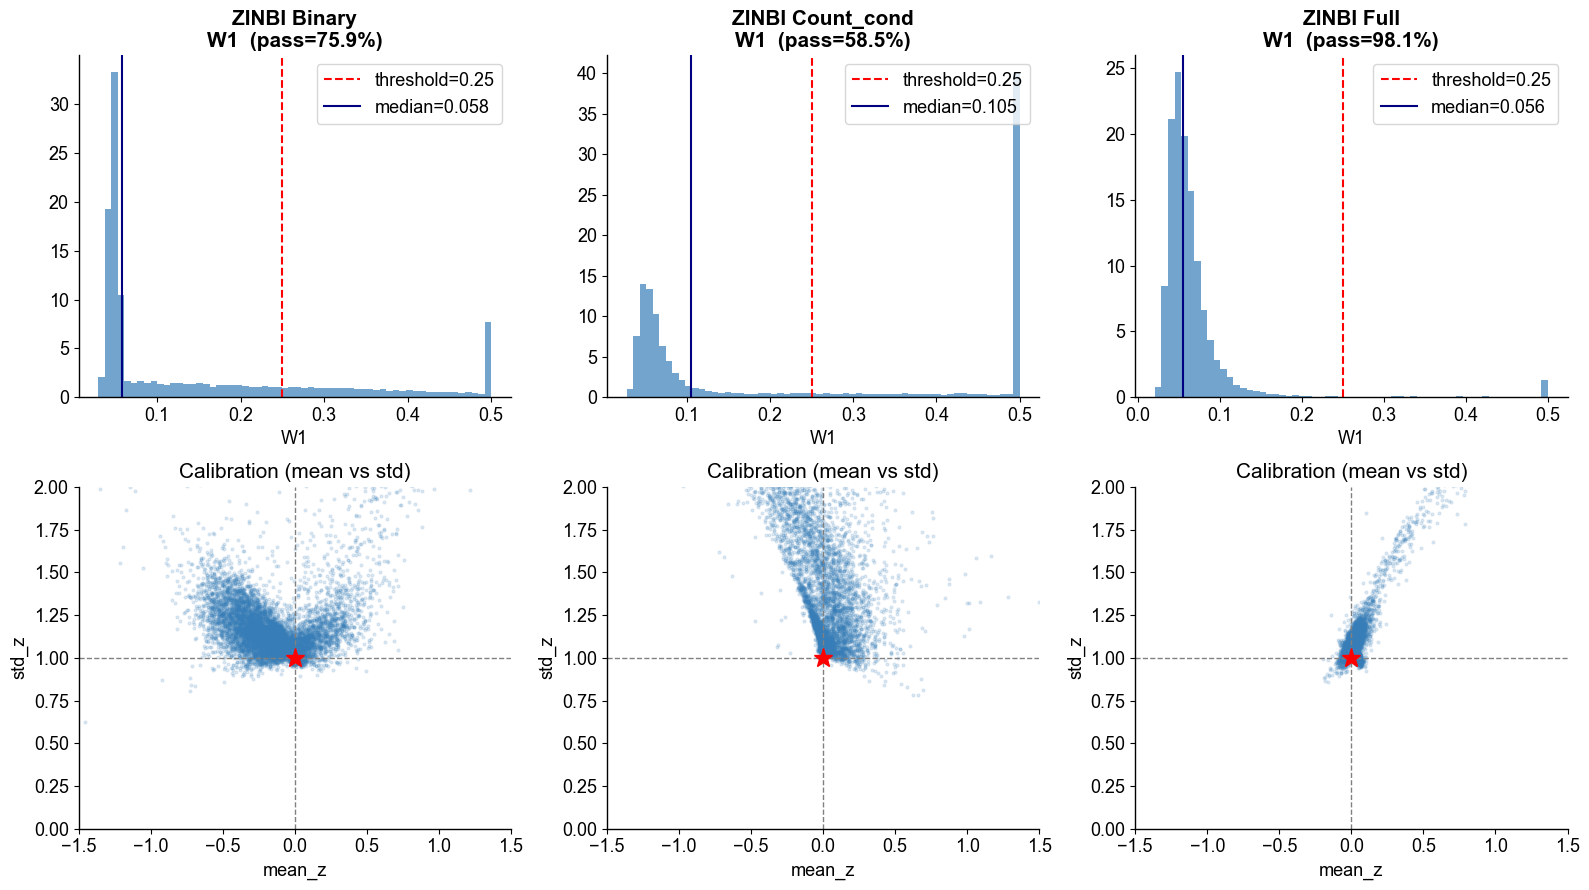

In [7]:
# ── ZINBI: Three Z-score Types ────────────────────────────────────
if zinb is not None:
    W1_THR = 0.25
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    zscore_types = [
        ('Binary',     'w1_binary',    'mean_binary_z',    'std_binary_z'),
        ('Count_cond', 'w1_count_cond','mean_count_cond_z','std_count_cond_z'),
        ('Full',       'w1_full',      'mean_full_z',      'std_full_z'),
    ]

    for ci, (ztype, w1_col, mz_col, sz_col) in enumerate(zscore_types):
        ax_w1  = axes[0, ci]
        ax_cal = axes[1, ci]

        # W1 distribution
        vals = zinb[w1_col].dropna().clip(0, 0.5)
        ax_w1.hist(vals, bins=60, color=PALETTE['ZINBI'], alpha=0.7, density=True)
        ax_w1.axvline(W1_THR, color='red',  lw=1.5, ls='--',
                      label=f'threshold={W1_THR}')
        med_w1 = zinb[w1_col].median()
        ax_w1.axvline(med_w1, color='navy', lw=1.5, ls='-',
                      label=f'median={med_w1:.3f}')
        pass_rate = (zinb[w1_col] <= W1_THR).mean() * 100
        ax_w1.set_title(f'ZINBI {ztype}\nW1  (pass={pass_rate:.1f}%)',
                        fontweight='bold')
        ax_w1.set_xlabel('W1'); ax_w1.legend()

        # Calibration scatter
        mz = zinb[mz_col].dropna()
        sz = zinb[sz_col].dropna()
        idx = mz.index.intersection(sz.index)
        ax_cal.scatter(mz[idx], sz[idx], alpha=0.15, s=4, color=PALETTE['ZINBI'])
        ax_cal.axvline(0, color='grey', lw=1, ls='--')
        ax_cal.axhline(1, color='grey', lw=1, ls='--')
        ax_cal.plot(0, 1, 'r*', ms=14, zorder=5)
        ax_cal.set_xlim(-1.5, 1.5); ax_cal.set_ylim(0, 2)
        ax_cal.set_xlabel('mean_z'); ax_cal.set_ylabel('std_z')
        ax_cal.set_title('Calibration (mean vs std)')

    plt.tight_layout()
    plt.savefig(CV_DIR / "Figures" / 'fig_zinbi_zscore_types.png', bbox_inches='tight')
    plt.show()
else:
    print('ZINBI results not yet available.')

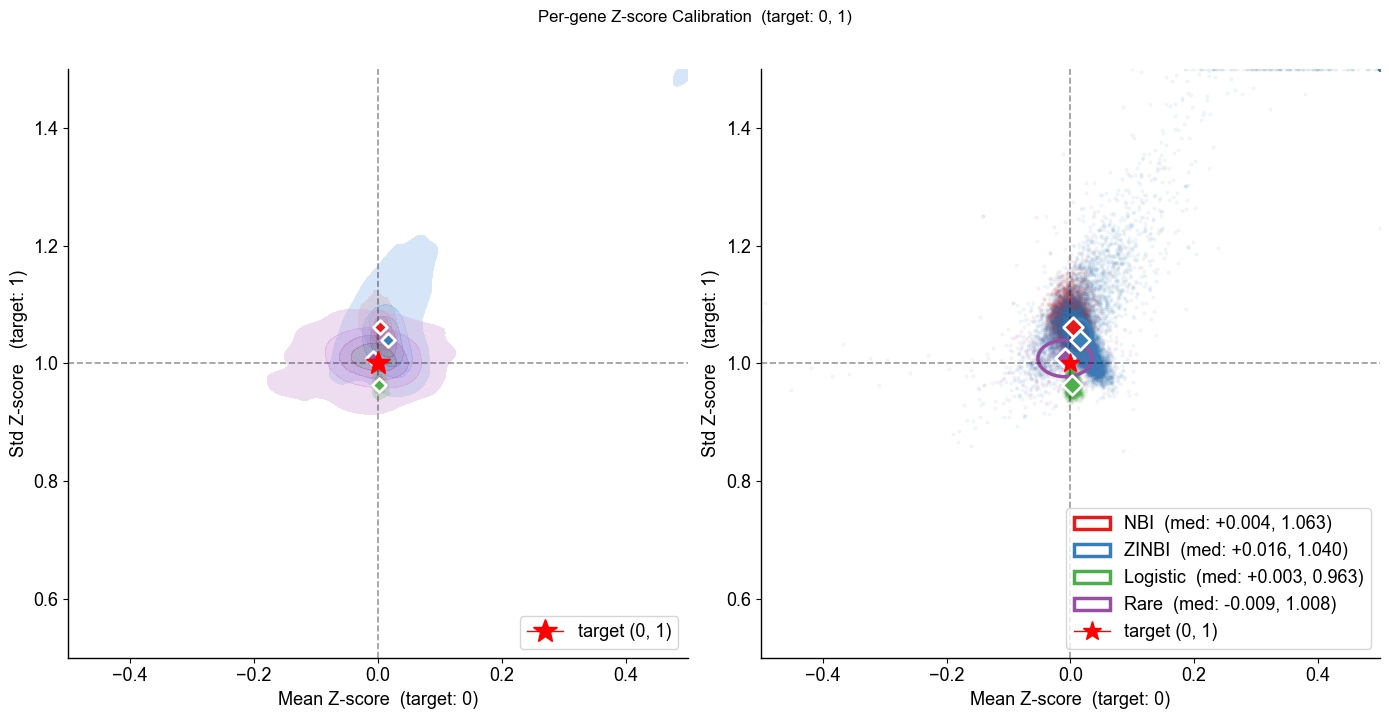

Model         med mean_z  med std_z  |mean_z|<0.1 %  |std_z-1|<0.1 %
------------------------------------------------------------------
NBI              +0.0041     1.0627          100.0%            95.2%
ZINBI            +0.0159     1.0398           96.8%            89.4%
Logistic         +0.0026     0.9629          100.0%           100.0%
Rare             -0.0087     1.0085           93.2%            99.8%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
xlim = (-0.5, 0.5)
ylim = (0.5, 1.5)

# ── Left: 2D KDE contour ──────────────────────────────────────────
ax = axes[0]
for model in models_present:
    sub = all_df[all_df['model'] == model].dropna(subset=['mean_z', 'std_z'])
    mz  = sub['mean_z'].clip(*xlim)
    sz  = sub['std_z'].clip(*ylim)
    sns.kdeplot(x=mz, y=sz, ax=ax, label=model,
                color=PALETTE[model], levels=5,
                fill=True, alpha=0.40, linewidths=1.5)
    ax.scatter(mz.median(), sz.median(), color=PALETTE[model],
               s=50, zorder=6, edgecolors='white', linewidth=2, marker='D')
ax.axvline(0, color='black', lw=1.2, ls='--', alpha=0.4)
ax.axhline(1, color='black', lw=1.2, ls='--', alpha=0.4)
ax.plot(0, 1, marker='*', ms=18, color='red', zorder=7, label='target (0, 1)')
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xlabel('Mean Z-score  (target: 0)')
ax.set_ylabel('Std Z-score   (target: 1)')
ax.legend(loc='lower right')

# ── Right: scatter + IQR ellipse ─────────────────────────────────
ax = axes[1]
for model in models_present:
    sub = all_df[all_df['model'] == model].dropna(subset=['mean_z', 'std_z'])
    mz  = sub['mean_z'].clip(*xlim)
    sz  = sub['std_z'].clip(*ylim)
    ax.scatter(mz, sz, alpha=0.05, s=4, color=PALETTE[model])
    q25_mz, q75_mz = mz.quantile(0.25), mz.quantile(0.75)
    q25_sz, q75_sz = sz.quantile(0.25), sz.quantile(0.75)
    ellipse = plt.matplotlib.patches.Ellipse(
        xy=(mz.median(), sz.median()),
        width=(q75_mz - q25_mz) * 1.5,
        height=(q75_sz - q25_sz) * 1.5,
        edgecolor=PALETTE[model], facecolor='none', lw=2.5,
        label=f'{model}  (med: {mz.median():+.3f}, {sz.median():.3f})'
    )
    ax.add_patch(ellipse)
    ax.scatter(mz.median(), sz.median(), color=PALETTE[model],
               s=100, zorder=6, edgecolors='white', linewidth=2, marker='D')
ax.axvline(0, color='black', lw=1.2, ls='--', alpha=0.4)
ax.axhline(1, color='black', lw=1.2, ls='--', alpha=0.4)
ax.plot(0, 1, marker='*', ms=14, color='red', zorder=7, label='target (0, 1)')
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xlabel('Mean Z-score  (target: 0)')
ax.set_ylabel('Std Z-score   (target: 1)')
ax.legend(loc='lower right')

plt.suptitle('Per-gene Z-score Calibration  (target: 0, 1)',
             y=1.02)
plt.tight_layout()
plt.savefig(CV_DIR / "Figures" / 'fig_calibration_2d.png', bbox_inches='tight')
plt.show()

print(f"{'Model':<12} {'med mean_z':>11} {'med std_z':>10} "
      f"{'|mean_z|<0.1 %':>15} {'|std_z-1|<0.1 %':>16}")
print('-' * 66)
for model in models_present:
    sub = all_df[all_df['model'] == model].dropna(subset=['mean_z', 'std_z'])
    m   = sub['mean_z'].median()
    s   = sub['std_z'].median()
    pm  = (sub['mean_z'].abs() < 0.1).mean() * 100
    ps  = ((sub['std_z'] - 1).abs() < 0.1).mean() * 100
    print(f"{model:<12} {m:>+11.4f} {s:>10.4f} {pm:>14.1f}% {ps:>15.1f}%")

In [9]:
import scanpy as sc
from scipy.sparse import issparse

H5AD = config.H5AD_PATH

def _load_ppc_pkl(path):
    import pickle
    if not path.exists():
        print(f' Missing : {path.name}'); return None
    with open(path, 'rb') as f:
        data = pickle.load(f)
    g0 = next(iter(data))
    print(f'  {path.name}: {len(data):,} genes  keys={list(data[g0].keys())}')
    return data

print('PPC parameter files:')
ppc_raw = {
    'NBI': _load_ppc_pkl(CV_DIR / 'cv_gamlss_nb_ppc.pkl'),
    'ZINBI': _load_ppc_pkl(CV_DIR / 'cv_zinb_ppc.pkl'),
}
ppc_raw = {k: v for k, v in ppc_raw.items() if v is not None}

if ppc_raw:
    print('\nLoading HC counts from h5ad...')
    adata = sc.read_h5ad(H5AD)
    adata = adata[adata.obs['QC_Passed'] == True]
    adata = adata[adata.obs['Phenotype_Processed'].notna()]
    adata = adata[adata.obs['Phenotype_Processed'] != 'Unknown']
    adata = adata[adata.obs['broad_protocol_category'] != 'Exome-based (EB)']
    is_hc = (adata.obs['Phenotype_Processed'].astype(str) == 'Healthy Control').values
    Y_ppc = adata.X[is_hc]
    if issparse(Y_ppc): Y_ppc = Y_ppc.toarray()
    Y_ppc = np.round(Y_ppc).astype(np.float32)
    gene_idx = {g: i for i, g in enumerate(adata.var_names)}
    print(f'  HC={is_hc.sum()}, genes={len(gene_idx):,}')

SIM_FN = cmp.SIM_FN

ppc_dfs = {}
for model, raw in ppc_raw.items():
    records, seed = [], 42
    for gene, params in raw.items():
        gi = gene_idx.get(gene, -1)
        if gi < 0: continue
        y = Y_ppc[:, gi]
        valid = np.isfinite(params['mu']) & np.isfinite(params['sigma'])
        if 'nu' in params: valid &= np.isfinite(params['nu'])
        if valid.sum() < 10: continue
        p_v = {k: v[valid] for k, v in params.items()}
        y_v = y[valid]
        y_sim = SIM_FN[model](p_v, seed)
        records.append({
            'gene': gene,
            'real_mean': float(y_v.mean()), 'sim_mean': float(y_sim.mean()),
            'real_std': float(y_v.std()), 'sim_std': float(y_sim.std()),
            'real_det': float((y_v > 0).mean()), 'sim_det': float((y_sim > 0).mean()),
        })
        seed += 1
    ppc_dfs[model] = pd.DataFrame(records)
    print(f'{model}: PPC computed for {len(ppc_dfs[model]):,} genes')

PPC parameter files:
  cv_gamlss_nb_ppc.pkl: 16,570 genes  keys=['mu', 'sigma']


  cv_zinb_ppc.pkl: 16,572 genes  keys=['mu', 'sigma', 'nu']

Loading HC counts from h5ad...


  HC=693, genes=78,691


NBI: PPC computed for 16,568 genes


ZINBI: PPC computed for 16,569 genes


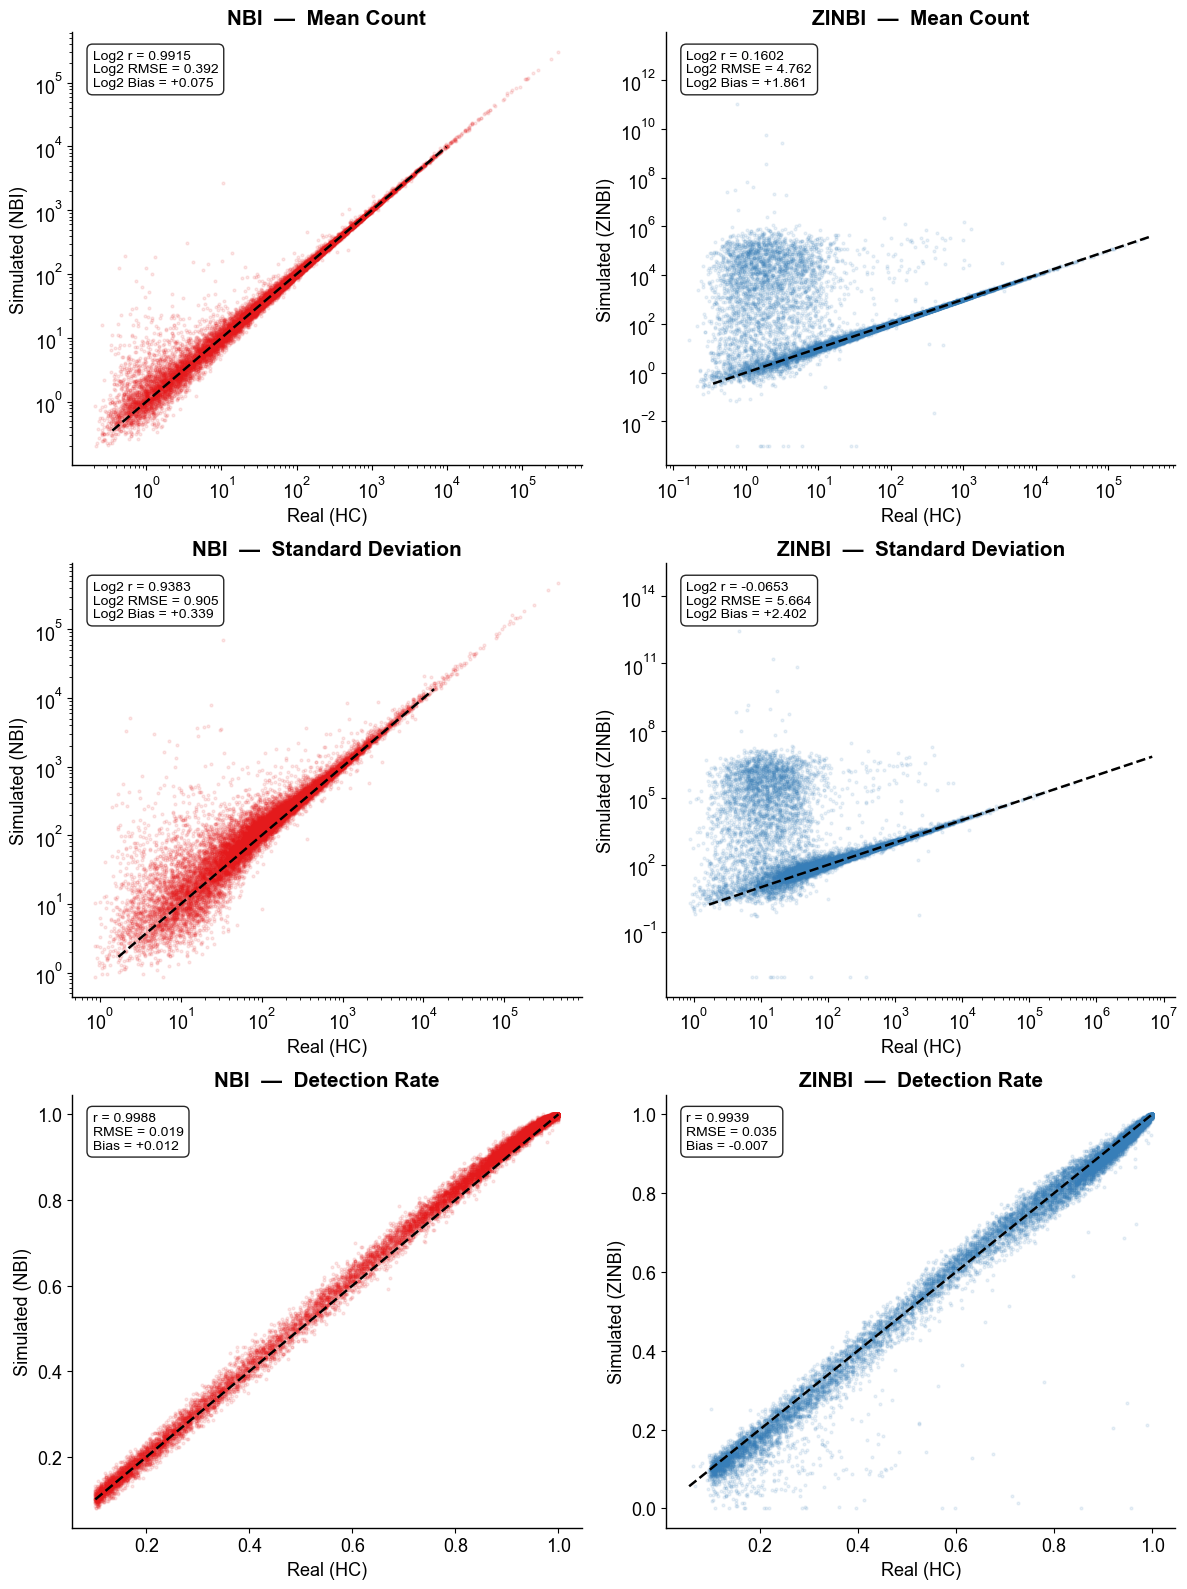


Model    Statistic                     r       RMSE         Bias
──────────────────────────────────────────────────────────────────
NBI      Log2 Mean Count          0.9915      0.392       +0.075
NBI      Log2 Standard Deviation   0.9383      0.905       +0.339
NBI      Detection Rate           0.9988      0.019       +0.012
ZINBI    Log2 Mean Count          0.1602      4.762       +1.861
ZINBI    Log2 Standard Deviation  -0.0653      5.664       +2.402
ZINBI    Detection Rate           0.9939      0.035       -0.007


In [10]:
ppc_models = list(ppc_dfs.keys())
n_ppc = len(ppc_models)
stats = [
    ('real_mean', 'sim_mean', 'Mean Count', 'log'),
    ('real_std', 'sim_std', 'Standard Deviation', 'log'),
    ('real_det', 'sim_det', 'Detection Rate', 'linear'),
]

fig, axes = plt.subplots(3, n_ppc, figsize=(6 * n_ppc, 16), squeeze=False)

stats_results = []

for col, model in enumerate(ppc_models):
    df = ppc_dfs[model].dropna()
    color = PALETTE.get(model, '#888888')

    for row, (rx, sy, title, scale) in enumerate(stats):
        ax = axes[row, col]
        x = df[rx].clip(lower=1e-3)
        y = df[sy].clip(lower=1e-3)

        ax.scatter(x, y, alpha=0.10, s=4, color=color, rasterized=True)
        lo = min(x.quantile(0.005), y.quantile(0.005))
        hi = max(x.quantile(0.995), y.quantile(0.995))
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1.8, label='y = x')

        v = np.isfinite(x) & np.isfinite(y)
        x_val, y_val = x[v], y[v]

        if scale == 'log':
            x_stat = np.log2(x_val + 1.0)
            y_stat = np.log2(y_val + 1.0)
            prefix = 'Log2 '
        else:
            x_stat = x_val
            y_stat = y_val
            prefix = ''

        corr = np.corrcoef(x_stat, y_stat)[0, 1]
        rmse = np.sqrt(((x_stat - y_stat) ** 2).mean())
        bias = (y_stat - x_stat).mean()

        stats_results.append((model, title, corr, rmse, bias, prefix))

        ax.text(0.04, 0.96,
                f'{prefix}r = {corr:.4f}\n{prefix}RMSE = {rmse:.3f}\n{prefix}Bias = {bias:+.3f}',
                transform=ax.transAxes, va='top',
                bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85))

        if scale == 'log':
            ax.set_xscale('log'); ax.set_yscale('log')

        ax.set_xlabel('Real (HC)')
        ax.set_ylabel(f'Simulated ({model})')
        ax.set_title(f'{model}  —  {title}', fontweight='bold')

plt.tight_layout()
plt.savefig(CV_DIR / "Figures" / 'fig_ppc_fold.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n{'Model':<8} {'Statistic':<22} {'r':>8} {'RMSE':>10} {'Bias':>12}")
print('─' * 66)
for res in stats_results:
    model, title, corr, rmse, bias, prefix = res
    label = f"{prefix}{title}"
    print(f"{model:<8} {label:<22} {corr:>8.4f} {rmse:>10.3f} {bias:>+12.3f}")

# Rare branch — pooled covariate-noise GLM

The rare branch (det < 1%, 559 protein-coding genes) is a single pooled GLM shared across all
rare genes: `log(mu_ij) = log(mean_hc_j + eps) [offset] + beta^T x_i [shared]`, scored with the
project-standard RQR. Below: held-out HC calibration, covariate drivers of background noise, the
QQ-tail / HC false-positive diagnosis, and the group-level disease-vs-HC enrichment that turns
single-cell anomalies into evidence. (Engine-branch artifacts: `engine_state/rare_glm.pkl`,
`Z_scores/Z_rare_disease.npy`.)

In [11]:
from model_engine import NormativeModelEngine
from pipeline import data_prep
from scipy import stats as sps

engine = NormativeModelEngine.load(config.ENGINE_DIR)
glm = engine.rare_glm
print('rare family:', glm['family'], ' deviance/df:', round(glm['overdisp_ratio'], 3),
      ' eps:', round(glm['eps'], 6))

genes_order = list(rare_z.keys())
adata_r = data_prep.load_adata()
is_hc_r, _, _ = data_prep.make_phenotypes(adata_r)
col_of = {g: i for i, g in enumerate(adata_r.var_names)}
Y_all = data_prep.count_matrix(adata_r)
Y_hc_rare = Y_all[is_hc_r][:, [col_of[g] for g in genes_order]]
Z_hc_rare = np.column_stack([rare_z[g] for g in genes_order])
finite = np.isfinite(Z_hc_rare.ravel())
z_flat = Z_hc_rare.ravel()[finite]
y_flat = Y_hc_rare.ravel()[finite]
print('held-out HC z:', z_flat.shape, ' mean=%.3f std=%.3f' % (z_flat.mean(), z_flat.std()))

Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (20097 fitted genes)
rare family: poisson  deviance/df: 0.213  eps: 0.000722


held-out HC z: (387387,)  mean=-0.019 std=1.011


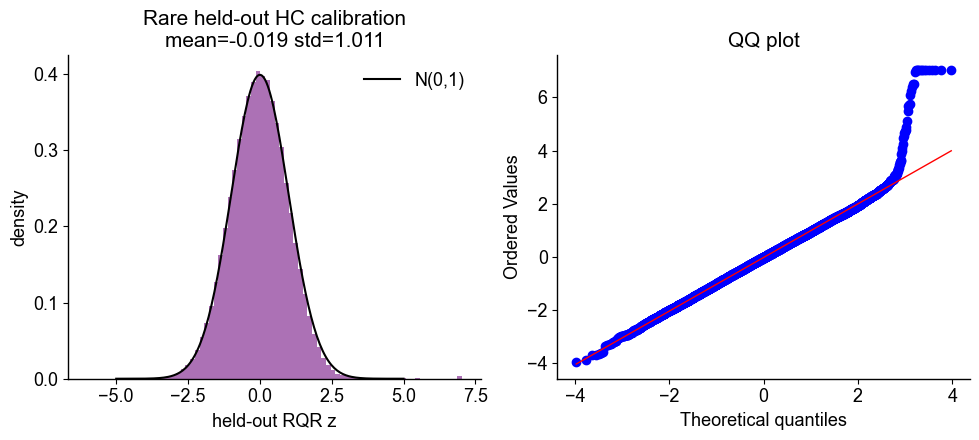

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].hist(z_flat, bins=80, density=True, color=PALETTE['Rare'], alpha=0.8)
xs = np.linspace(-5, 5, 200)
axes[0].plot(xs, norm.pdf(xs), color='black', lw=1.5, label='N(0,1)')
axes[0].set_xlabel('held-out RQR z'); axes[0].set_ylabel('density'); axes[0].legend(frameon=False)
axes[0].set_title('Rare held-out HC calibration\nmean=%.3f std=%.3f' % (z_flat.mean(), z_flat.std()))
samp = np.random.default_rng(0).choice(len(z_flat), min(20000, len(z_flat)), replace=False)
sps.probplot(z_flat[samp], dist='norm', plot=axes[1])
axes[1].set_title('QQ plot')
fig.tight_layout()
plt.savefig(CV_DIR / 'Figures' / 'fig_rare_calibration.png', bbox_inches='tight')
plt.show()

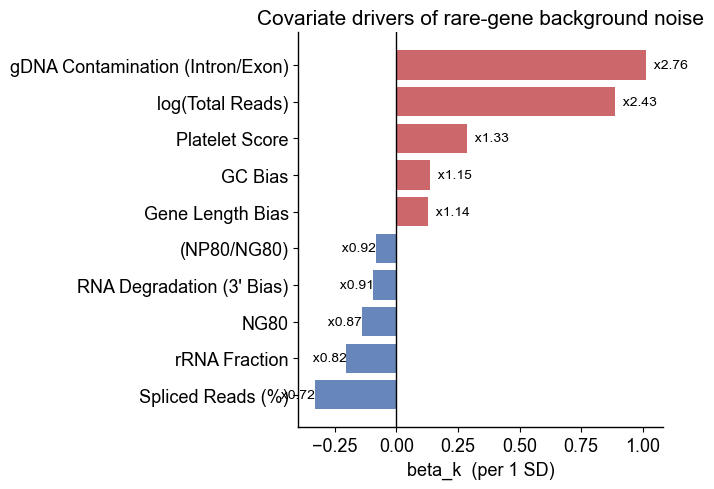

,beta,fold_per_sd
covariate,,
Spliced Reads (%),-0.331,0.718
rRNA Fraction,-0.203,0.816
NG80,-0.142,0.868
RNA Degradation (3' Bias),-0.094,0.911
(NP80/NG80),-0.084,0.920
Gene Length Bias,0.129,1.138
GC Bias,0.138,1.148
Platelet Score,0.288,1.334
log(Total Reads),0.888,2.429


In [13]:
beta = glm['beta'][1:]
eff = pd.DataFrame({'covariate': config.BIAS_COLUMNS, 'beta': beta}).sort_values('beta')
eff['fold_per_sd'] = np.exp(eff['beta'])
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#C44E52' if b > 0 else '#4C72B0' for b in eff['beta']]
ax.barh(eff['covariate'], eff['beta'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('beta_k  (per 1 SD)')
ax.set_title('Covariate drivers of rare-gene background noise')
for yi, f in enumerate(eff['fold_per_sd']):
    b = eff['beta'].iloc[yi]
    ax.text(b, yi, '  x%.2f' % f, va='center', ha='left' if b >= 0 else 'right', fontsize=10)
fig.tight_layout()
plt.savefig(CV_DIR / 'Figures' / 'fig_rare_covariates.png', bbox_inches='tight')
plt.show()
eff.set_index('covariate').round(3)

thr     empirical HC   nominal   enrichment   detected(y>=1) share
  |z|>=2:  4.3063%    4.5500%   0.95x       8.6%
  |z|>=3:  0.4388%    0.2700%   1.63x       58.8%
  |z|>=4:  0.1397%    0.0063%   22.05x       95.6%


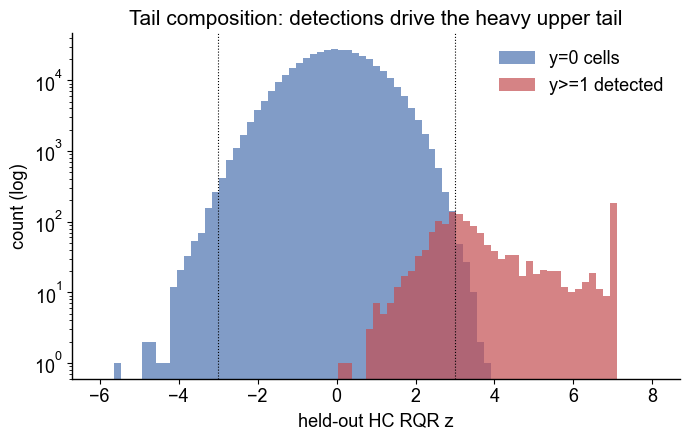

In [14]:
print('thr     empirical HC   nominal   enrichment   detected(y>=1) share')
for thr in [2.0, 3.0, 4.0]:
    fl = np.abs(z_flat) >= thr
    emp = fl.mean(); nom = 2 * norm.sf(thr)
    frac_det = (y_flat[fl] > 0).mean() if fl.any() else 0.0
    print('  |z|>=%.0f:  %.4f%%    %.4f%%   %.2fx       %.1f%%' % (thr, emp*100, nom*100, emp/nom, frac_det*100))

fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(-6, 8, 80)
ax.hist(z_flat[y_flat == 0], bins=bins, color='#4C72B0', alpha=0.7, label='y=0 cells', log=True)
ax.hist(z_flat[y_flat > 0], bins=bins, color='#C44E52', alpha=0.7, label='y>=1 detected', log=True)
ax.axvline(3.0, color='black', lw=0.8, ls=':'); ax.axvline(-3.0, color='black', lw=0.8, ls=':')
ax.set_xlabel('held-out HC RQR z'); ax.set_ylabel('count (log)')
ax.set_title('Tail composition: detections drive the heavy upper tail'); ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(CV_DIR / 'Figures' / 'fig_rare_tails.png', bbox_inches='tight')
plt.show()

rare genes enriched in disease vs HC baseline (FDR<0.05): 147 / 559


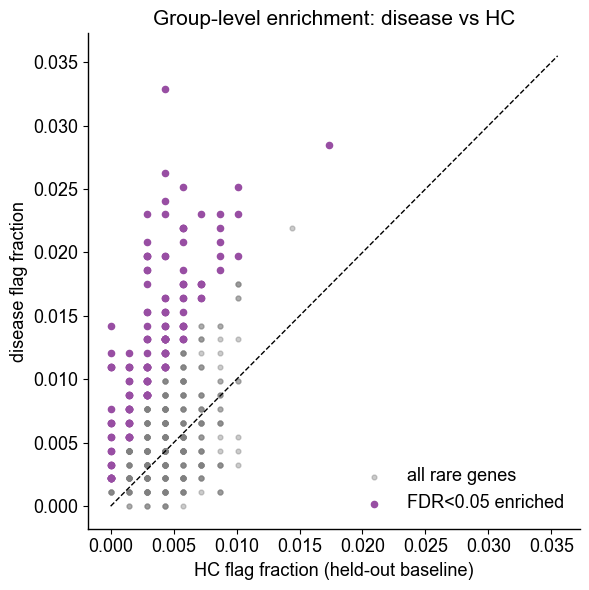

,gene,n_dis_flag,dis_flag,hc_flag,p_enrich,fdr
170,ENSG00000182415.11,30,0.032859,0.004329,4.638332e-17,4.321380e-15
403,ENSG00000244025.5,26,0.028478,0.017316,1.080793e-02,4.249387e-02
134,ENSG00000176922.5,24,0.026287,0.004329,6.264087e-12,4.377031e-10
125,ENSG00000176200.1,23,0.025192,0.010101,8.587315e-05,8.571981e-04
59,ENSG00000150750.9,23,0.025192,0.005772,8.590907e-09,2.286818e-07
346,ENSG00000228567.3,22,0.024096,0.004329,2.344051e-10,1.191204e-08
112,ENSG00000172468.14,21,0.023001,0.010101,5.535941e-04,3.773892e-03
114,ENSG00000172680.1,21,0.023001,0.004329,1.342013e-09,4.167694e-08
147,ENSG00000179615.3,21,0.023001,0.008658,7.288960e-05,7.408233e-04
431,ENSG00000258436.2,21,0.023001,0.002886,9.149085e-13,7.306198e-11


In [15]:
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests

Z_FLAG = config.MODELING_PARAMS['z_flag']
hc_flag = {g: float((np.abs(rare_z[g]) >= Z_FLAG).mean()) for g in genes_order}
rg = np.load(config.Z_RARE_GENE_NAMES, allow_pickle=True).tolist()
Z_rare_dis = np.load(config.Z_RARE_DISEASE)
n_dis = Z_rare_dis.shape[0]
enr = pd.DataFrame({'gene': rg,
                    'n_dis_flag': (np.abs(Z_rare_dis) >= Z_FLAG).sum(axis=0),
                    'dis_flag': (np.abs(Z_rare_dis) >= Z_FLAG).mean(axis=0)})
enr['hc_flag'] = enr['gene'].map(hc_flag).fillna(0.0)
enr['p_enrich'] = [binomtest(int(k), n_dis, max(p, 1e-4), 'greater').pvalue
                   for k, p in zip(enr['n_dis_flag'], enr['hc_flag'])]
enr['fdr'] = multipletests(enr['p_enrich'], method='fdr_bh')[1]
sig = enr[enr['fdr'] < 0.05].sort_values('dis_flag', ascending=False)
print('rare genes enriched in disease vs HC baseline (FDR<0.05): %d / %d' % (len(sig), len(enr)))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(enr['hc_flag'], enr['dis_flag'], s=12, alpha=0.4, color='grey', label='all rare genes')
ax.scatter(sig['hc_flag'], sig['dis_flag'], s=20, color=PALETTE['Rare'], label='FDR<0.05 enriched')
lim = max(enr['hc_flag'].max(), enr['dis_flag'].max()) * 1.05 + 1e-3
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlabel('HC flag fraction (held-out baseline)'); ax.set_ylabel('disease flag fraction')
ax.set_title('Group-level enrichment: disease vs HC'); ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(CV_DIR / 'Figures' / 'fig_rare_enrichment.png', bbox_inches='tight')
plt.show()
sig.head(15)